# Seasonal Agriculture Performance Analysis

**Major Project — Data Analytics**

This notebook analyzes agricultural activities across different seasons (**Kharif, Rabi, Zaid**), geographies and farming conditions to uncover seasonal patterns, trends, relationships and differences in agricultural performance.

**Sections:**
1. Introduction & Problem Statement
2. Import Libraries
3. Load Dataset
4. Initial Data Exploration
5. Data Cleaning & Preparation
6. Feature Engineering
7. Univariate Analysis
8. Seasonal Performance Comparison
9. Relationships Between Environmental Conditions & Performance
10. Regional / Crop-wise Seasonal Patterns
11. Statistical Significance Testing
12. Correlation Analysis
13. Key Insights
14. Conclusions & Recommendations


## 1. Introduction & Problem Statement

**Problem Statement:** Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. This project analyzes the seasonal agriculture dataset to investigate how agricultural performance (yield, production, cost, revenue, profit, water usage, disease/pest risk) differs across seasons, and to identify meaningful patterns, trends, relationships and variations.

**Objective:** Explore, clean, analyze and visualize the dataset to compare seasonal agricultural performance, identify significant differences, and derive evidence-based insights and recommendations.


## 2. Import Libraries

In [1]:
# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy import stats
from scipy.stats import f_oneway, kruskal, chi2_contingency, pearsonr

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")


Libraries imported successfully.


## 3. Load Dataset

If you are running this in **Google Colab**, upload `seasonal_agriculture_performance_dataset.csv` using the file upload widget below, or mount Google Drive and point to the file path.


In [39]:

file_path = 'seasonal_agriculture_performance_dataset.csv'

# Load dataset into a pandas DataFrame
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)


Dataset loaded successfully.
Shape of dataset: (4000, 28)


## 4. Initial Data Exploration

In [3]:
# First 5 rows of the dataset
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
# Dataset structure: column names, data types, non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [5]:
# Statistical summary of numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [6]:
# Check unique values in key categorical columns
print("Seasons:", df['Season'].unique())
print("Crops:", df['Crop'].unique())
print("States:", df['State'].nunique(), "unique states")
print("Districts:", df['District'].nunique(), "unique districts")
print("Irrigation Methods:", df['Irrigation_Method'].unique())


Seasons: ['Kharif' 'Rabi' 'Zaid']
Crops: ['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
States: 8 unique states
Districts: 10 unique districts
Irrigation Methods: ['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [7]:
# Check number of records per season (helps understand balance of dataset)
df['Season'].value_counts()


,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [8]:
# Check for missing values in each column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'Missing_Count': missing, 'Missing_Percent': missing_pct})
missing_summary[missing_summary['Missing_Count'] > 0]


,Missing_Count,Missing_Percent
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [9]:
# Check for duplicate rows / duplicate Farm_IDs
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate Farm_IDs:", df['Farm_ID'].duplicated().sum())


Fully duplicated rows: 0
Duplicate Farm_IDs: 0


## 5. Data Cleaning & Preparation

Based on the exploration above, we address:
- Missing values in `Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha`
- Potential outliers in numeric columns (e.g. extremely high yield/water-efficiency values that are not realistic)
- Consistent data types


In [10]:
# Make a working copy so the original data stays untouched
data = df.copy()

# ---- Handle missing values ----
# For continuous environmental/agronomic variables, fill missing values
# with the median of the SAME SEASON (more meaningful than a global median,
# since conditions vary a lot by season).
cols_to_impute = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_to_impute:
    data[col] = data.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

# Confirm no missing values remain
print("Remaining missing values:\n", data[cols_to_impute].isnull().sum())


Remaining missing values:
 Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


In [11]:
# ---- Detect and cap outliers using the IQR method ----
# Some numeric fields (e.g. Yield_Tonnes_Ha, Water_Efficiency_t_per_1000m3) contain
# extreme values that are unrealistic for typical farm records.
# We cap (winsorize) values outside 1.5*IQR instead of deleting rows, to preserve sample size.

def cap_outliers_iqr(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return series.clip(lower=lower, upper=upper)

outlier_cols = ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3', 'Production_Tonnes',
                'Profit_INR', 'Water_Used_m3']

for col in outlier_cols:
    before_max = data[col].max()
    data[col] = cap_outliers_iqr(data[col])
    after_max = data[col].max()
    print(f"{col}: max before capping = {before_max:.2f}, after capping = {after_max:.2f}")


Yield_Tonnes_Ha: max before capping = 101.44, after capping = 5.50
Water_Efficiency_t_per_1000m3: max before capping = 79.80, after capping = 10.38
Production_Tonnes: max before capping = 1424.40, after capping = 53.36
Profit_INR: max before capping = 4345421.00, after capping = 763567.00
Water_Used_m3: max before capping = 40902.00, after capping = 16171.25


In [12]:
# ---- Standardize categorical text (strip spaces, consistent case) ----
categorical_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']
for col in categorical_cols:
    data[col] = data[col].astype(str).str.strip()

# Convert Season to an ordered category for consistent plotting order
season_order = ['Kharif', 'Rabi', 'Zaid']
data['Season'] = pd.Categorical(data['Season'], categories=season_order, ordered=True)

print("Data cleaning complete. Final shape:", data.shape)
data.head()


Data cleaning complete. Final shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237.0,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953.0,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275.0,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834.0,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287.0,2.829,32.3


## 6. Feature Engineering

Creating a few derived metrics that make seasonal comparison easier.


In [13]:
# Profit margin (%) = Profit / Revenue * 100
data['Profit_Margin_pct'] = (data['Profit_INR'] / data['Revenue_INR']) * 100

# Cost per hectare
data['Cost_per_Hectare'] = data['Total_Cost_INR'] / data['Farm_Area_Hectares']

# Revenue per hectare
data['Revenue_per_Hectare'] = data['Revenue_INR'] / data['Farm_Area_Hectares']

# Total NPK (Nitrogen + Phosphorus + Potassium) applied per hectare
data['Total_NPK_kg_ha'] = data['Nitrogen_kg_ha'] + data['Phosphorus_kg_ha'] + data['Potassium_kg_ha']

data[['Profit_Margin_pct', 'Cost_per_Hectare', 'Revenue_per_Hectare', 'Total_NPK_kg_ha']].describe()


,Profit_Margin_pct,Cost_per_Hectare,Revenue_per_Hectare,Total_NPK_kg_ha
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,-46.942407,66660.084938,80215.109448,282.792725
std,152.574873,8845.644258,58262.570038,45.445874
min,-1461.851219,35807.382550,4439.466896,118.300000
25%,-60.192762,60597.205943,42325.161826,251.675000
50%,1.146236,66614.048166,67082.984401,281.600000
75%,29.865551,72739.977527,96800.414327,313.200000
max,83.746016,97185.351090,422793.509615,438.500000


## 7. Univariate Analysis

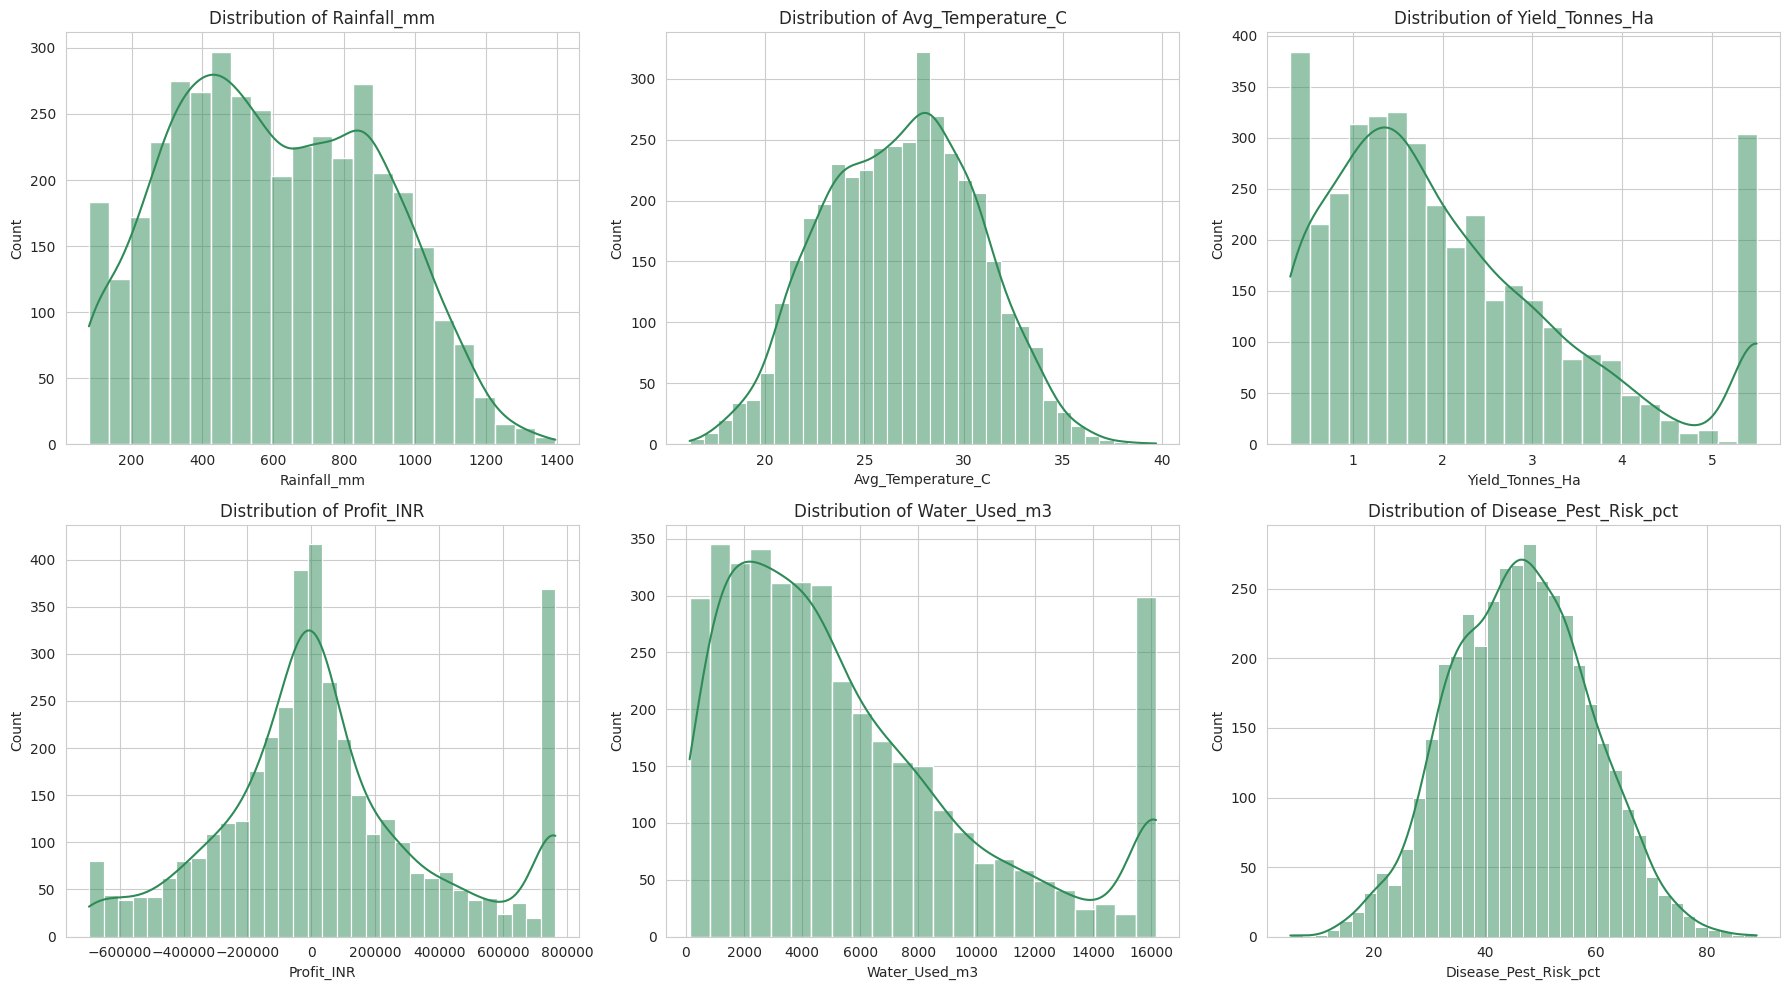

In [14]:
# Distribution of key numeric variables
num_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Yield_Tonnes_Ha', 'Profit_INR',
            'Water_Used_m3', 'Disease_Pest_Risk_pct']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(data[col], kde=True, ax=axes[i], color='seagreen')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


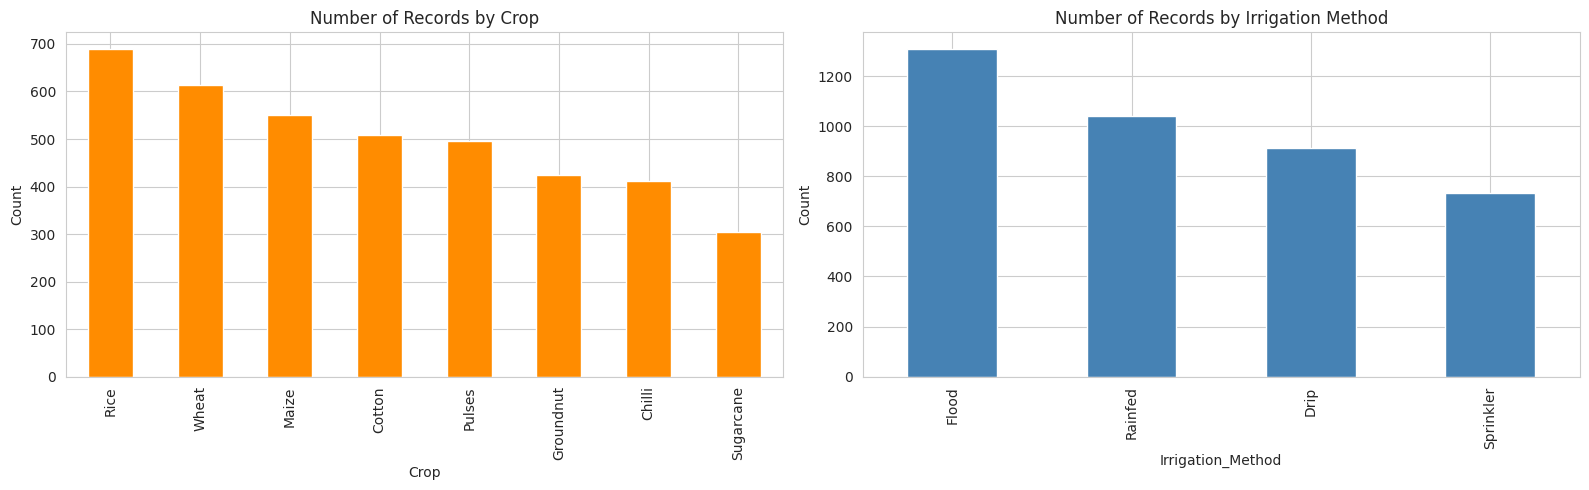

In [15]:
# Count of records by Crop and by Irrigation Method
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
data['Crop'].value_counts().plot(kind='bar', ax=axes[0], color='darkorange')
axes[0].set_title('Number of Records by Crop')
axes[0].set_ylabel('Count')

data['Irrigation_Method'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Number of Records by Irrigation Method')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


## 8. Seasonal Performance Comparison

Comparing key performance indicators (yield, production, cost, revenue, profit, water usage, disease risk) across the three seasons: **Kharif, Rabi, Zaid**.


In [16]:
# Aggregate key metrics by season (mean values)
seasonal_summary = data.groupby('Season').agg(
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temperature_C=('Avg_Temperature_C', 'mean'),
    Avg_Yield_Tonnes_Ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Production_Tonnes=('Production_Tonnes', 'mean'),
    Avg_Total_Cost_INR=('Total_Cost_INR', 'mean'),
    Avg_Revenue_INR=('Revenue_INR', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_Profit_Margin_pct=('Profit_Margin_pct', 'mean'),
    Avg_Water_Used_m3=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Pest_Risk_pct=('Disease_Pest_Risk_pct', 'mean'),
    Record_Count=('Farm_ID', 'count')
).round(2)

seasonal_summary


/tmp/ipykernel_1872/1713605198.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal_summary = data.groupby('Season').agg(


,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Total_Cost_INR,Avg_Revenue_INR,Avg_Profit_INR,Avg_Profit_Margin_pct,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Pest_Risk_pct,Record_Count
Season,,,,,,,,,,,,
Kharif,852.11,28.45,2.25,18.48,531804.41,710719.06,91727.66,-40.96,5680.51,4.04,54.47,1779
Rabi,435.94,23.49,2.03,16.53,513836.58,601526.05,39059.89,-45.36,5505.50,3.73,40.48,1627
Zaid,299.12,31.04,1.81,15.01,543976.73,519171.90,-51621.92,-69.21,5999.48,3.25,38.22,594


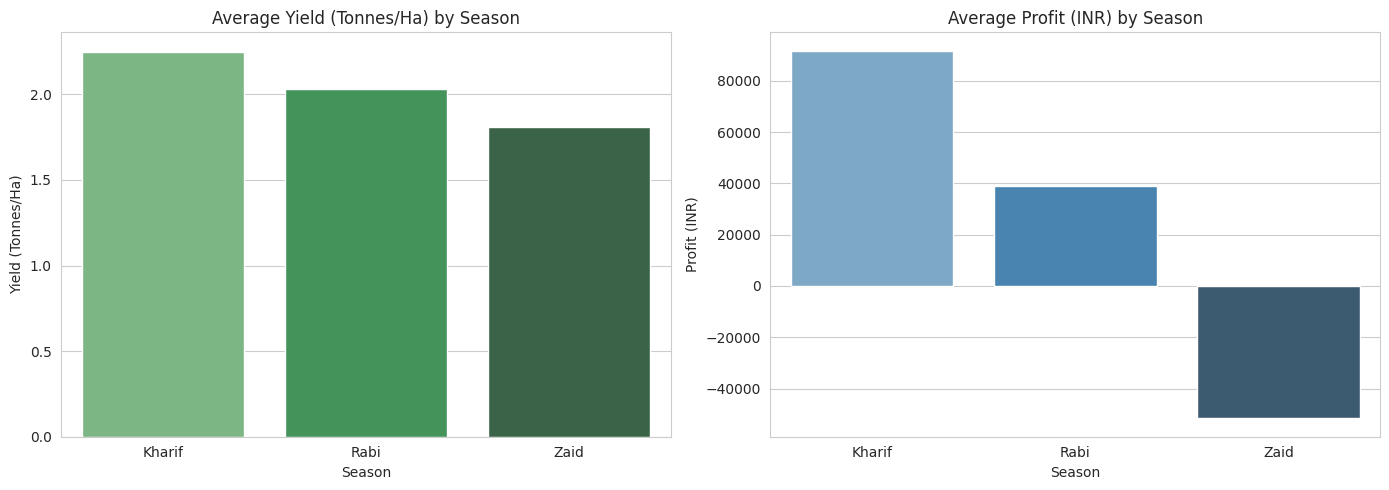

In [17]:
# Visualize average Yield and Profit across seasons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=seasonal_summary.index, y='Avg_Yield_Tonnes_Ha', data=seasonal_summary.reset_index(), ax=axes[0], hue=seasonal_summary.index, palette='Greens_d', legend=False)
axes[0].set_title('Average Yield (Tonnes/Ha) by Season')
axes[0].set_ylabel('Yield (Tonnes/Ha)')

sns.barplot(x=seasonal_summary.index, y='Avg_Profit_INR', data=seasonal_summary.reset_index(), ax=axes[1], hue=seasonal_summary.index, palette='Blues_d', legend=False)
axes[1].set_title('Average Profit (INR) by Season')
axes[1].set_ylabel('Profit (INR)')

plt.tight_layout()
plt.show()


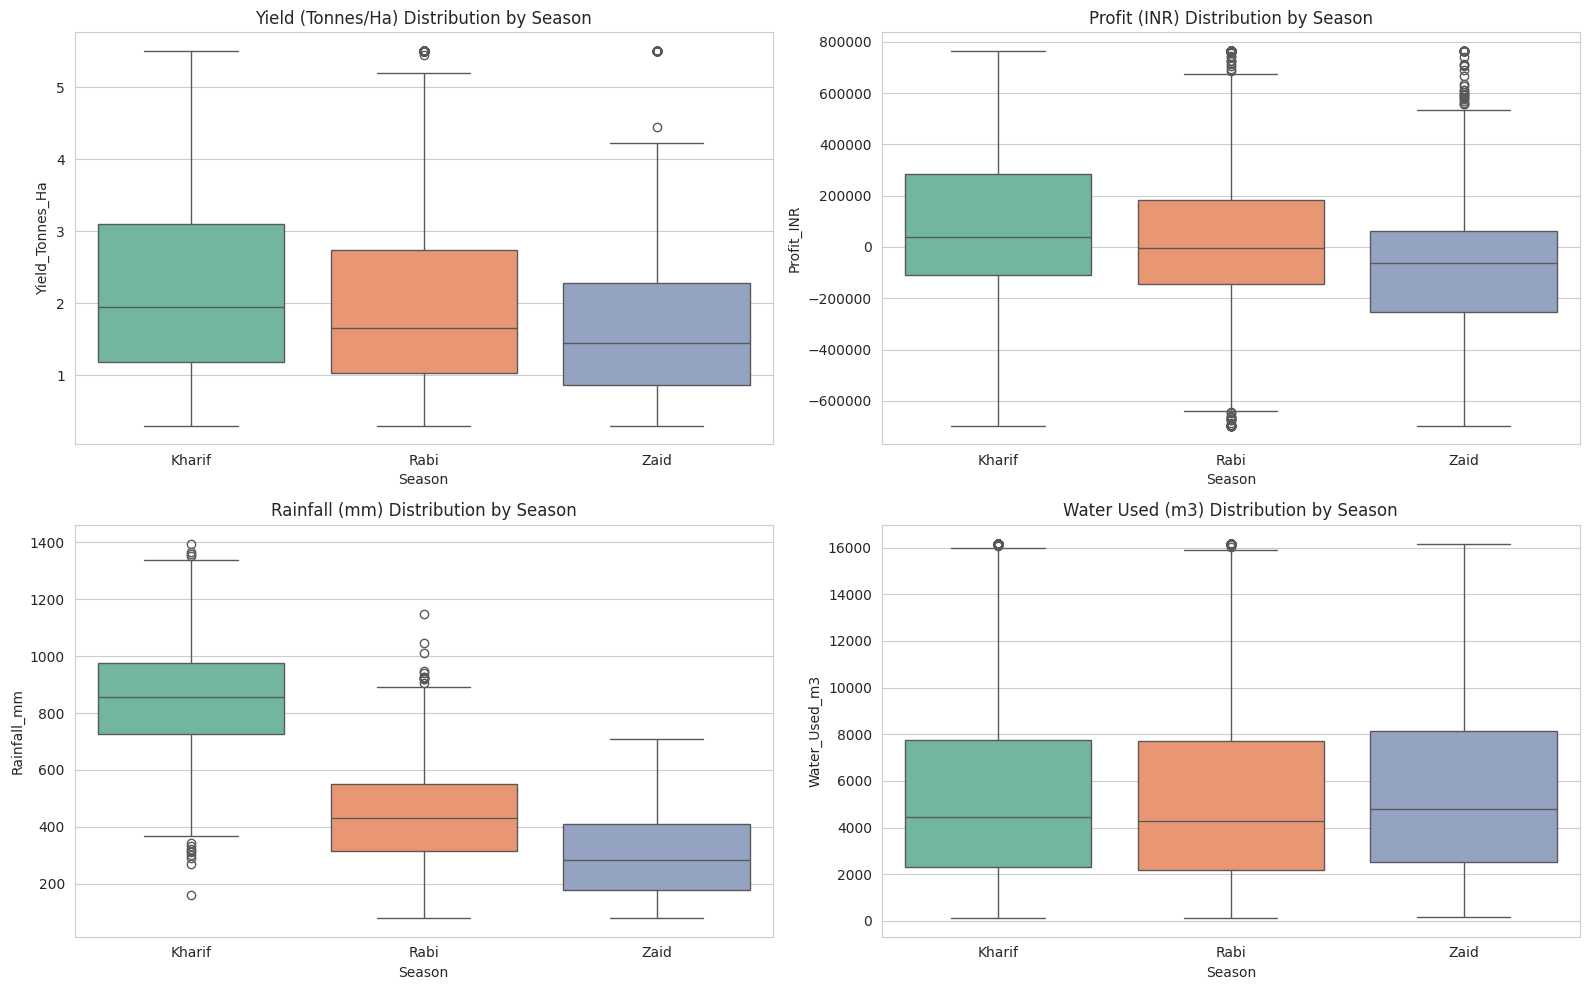

In [18]:
# Boxplots show spread/variation (not just averages) across seasons
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=data, ax=axes[0,0], hue='Season', palette='Set2', legend=False)
axes[0,0].set_title('Yield (Tonnes/Ha) Distribution by Season')

sns.boxplot(x='Season', y='Profit_INR', data=data, ax=axes[0,1], hue='Season', palette='Set2', legend=False)
axes[0,1].set_title('Profit (INR) Distribution by Season')

sns.boxplot(x='Season', y='Rainfall_mm', data=data, ax=axes[1,0], hue='Season', palette='Set2', legend=False)
axes[1,0].set_title('Rainfall (mm) Distribution by Season')

sns.boxplot(x='Season', y='Water_Used_m3', data=data, ax=axes[1,1], hue='Season', palette='Set2', legend=False)
axes[1,1].set_title('Water Used (m3) Distribution by Season')

plt.tight_layout()
plt.show()


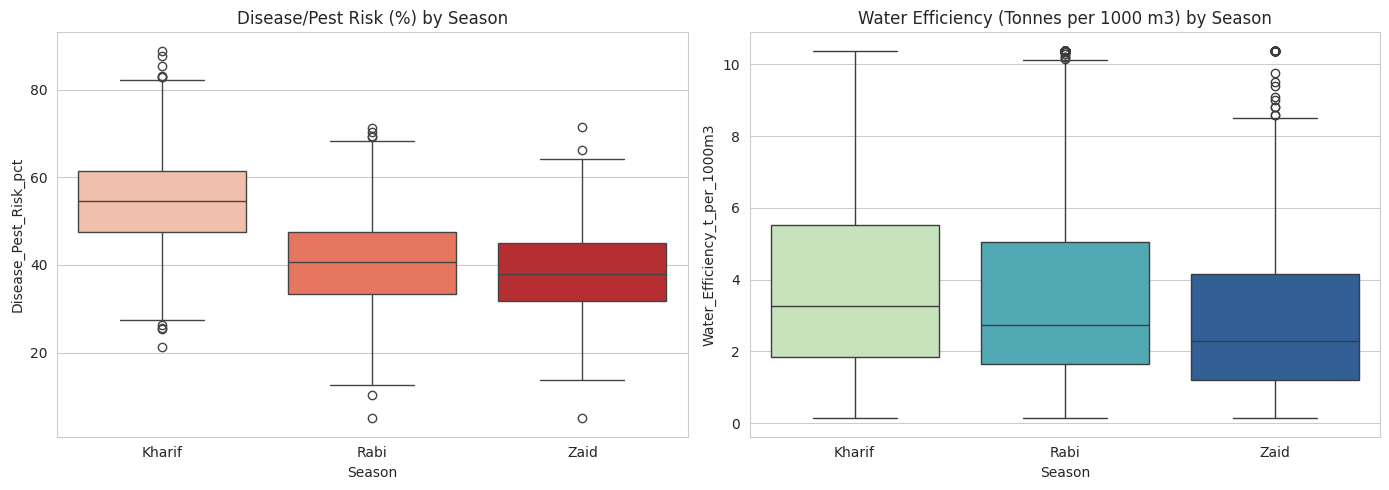

In [19]:
# Disease/Pest risk and Water Efficiency comparison across seasons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Season', y='Disease_Pest_Risk_pct', data=data, ax=axes[0], hue='Season', palette='Reds', legend=False)
axes[0].set_title('Disease/Pest Risk (%) by Season')

sns.boxplot(x='Season', y='Water_Efficiency_t_per_1000m3', data=data, ax=axes[1], hue='Season', palette='YlGnBu', legend=False)
axes[1].set_title('Water Efficiency (Tonnes per 1000 m3) by Season')

plt.tight_layout()
plt.show()


## 9. Crop and Regional Patterns Across Seasons

Examining whether seasonal patterns are consistent across different crops and states.


In [20]:
# Which crops are grown in which seasons? (cross-tabulation)
crop_season_ct = pd.crosstab(data['Crop'], data['Season'])
crop_season_ct


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


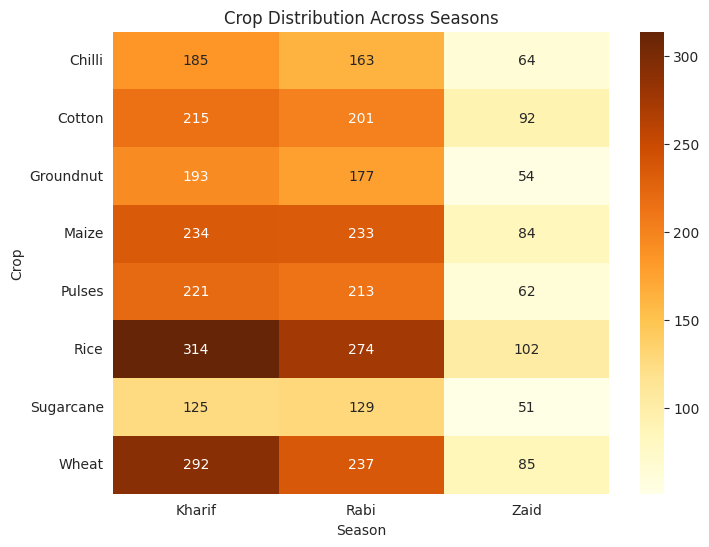

In [21]:
# Heatmap of crop distribution across seasons
plt.figure(figsize=(8, 6))
sns.heatmap(crop_season_ct, annot=True, fmt='d', cmap='YlOrBr')
plt.title('Crop Distribution Across Seasons')
plt.ylabel('Crop')
plt.xlabel('Season')
plt.show()


In [22]:
# Average yield by Crop and Season (which crop performs best in which season)
crop_season_yield = data.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().unstack().round(2)
crop_season_yield


/tmp/ipykernel_1872/1832489420.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crop_season_yield = data.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().unstack().round(2)


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.19
Cotton,1.38,1.20,0.96
Groundnut,1.49,1.23,1.04
Maize,2.96,2.60,2.29
Pulses,1.04,0.88,0.66
Rice,2.70,2.32,1.90
Sugarcane,5.43,5.38,5.42
Wheat,2.25,2.06,1.75


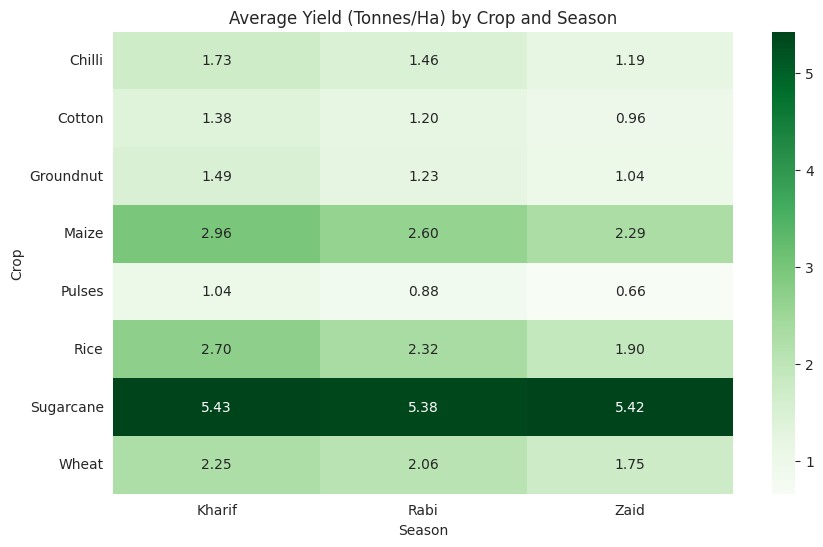

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(crop_season_yield, annot=True, fmt='.2f', cmap='Greens')
plt.title('Average Yield (Tonnes/Ha) by Crop and Season')
plt.show()


In [24]:
# Top 10 states by average profit, split by season
state_season_profit = data.groupby(['State', 'Season'])['Profit_INR'].mean().unstack().round(0)
state_season_profit


/tmp/ipykernel_1872/4114137936.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_season_profit = data.groupby(['State', 'Season'])['Profit_INR'].mean().unstack().round(0)


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,87542.0,-1942.0,-99268.0
Gujarat,114936.0,28402.0,-107196.0
Karnataka,92708.0,48303.0,8013.0
Madhya Pradesh,80049.0,21945.0,-47505.0
Maharashtra,84432.0,70127.0,-53790.0
Punjab,66718.0,76767.0,-5719.0
Tamil Nadu,91462.0,36963.0,-44260.0
Telangana,115280.0,32977.0,-61034.0


In [25]:
# Irrigation method usage across seasons
irrigation_season_ct = pd.crosstab(data['Irrigation_Method'], data['Season'], normalize='columns') * 100
irrigation_season_ct.round(1)


Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,22.8,22.7,23.6
Flood,33.2,32.3,32.7
Rainfed,26.0,26.9,23.6
Sprinkler,18.0,18.0,20.2


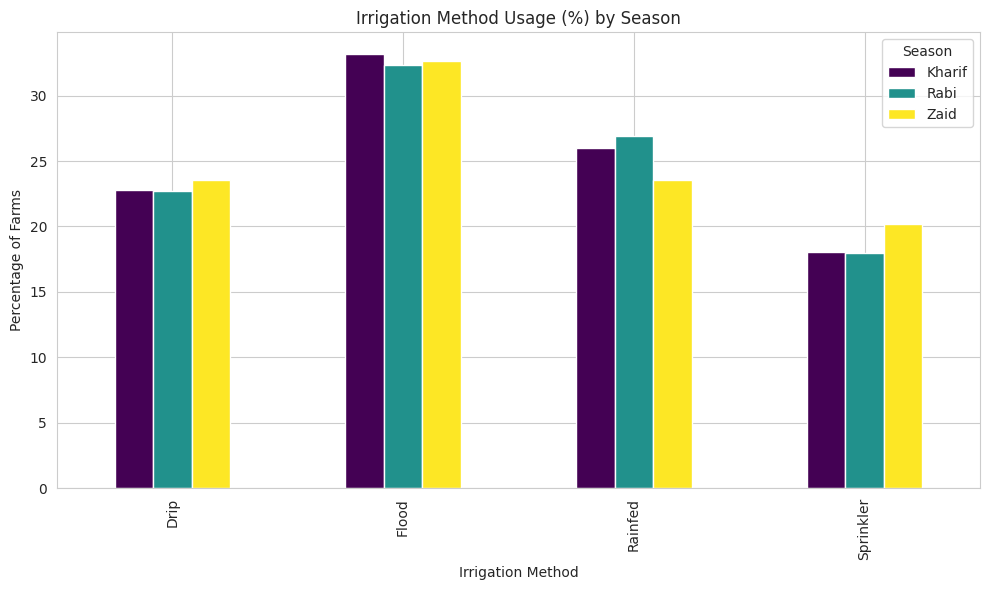

In [26]:
irrigation_season_ct.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Irrigation Method Usage (%) by Season')
plt.ylabel('Percentage of Farms')
plt.xlabel('Irrigation Method')
plt.legend(title='Season')
plt.tight_layout()
plt.show()


## 10. Relationships Between Environmental Conditions and Performance


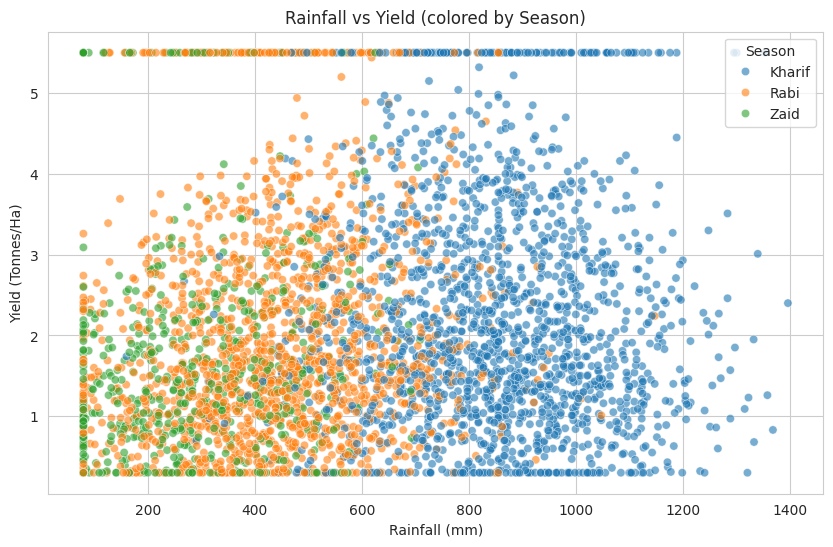

In [27]:
# Scatter plot: Rainfall vs Yield, colored by Season
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', data=data, alpha=0.6)
plt.title('Rainfall vs Yield (colored by Season)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()


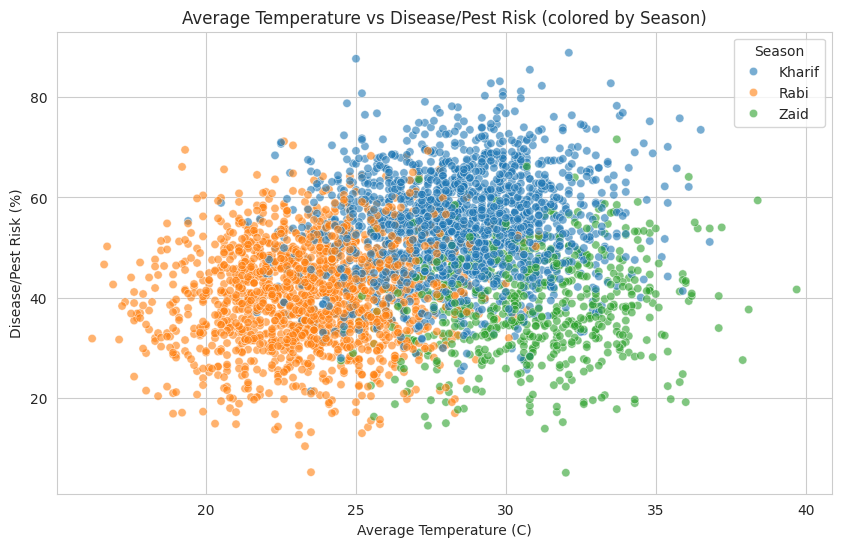

In [28]:
# Scatter plot: Temperature vs Disease/Pest Risk, colored by Season
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Avg_Temperature_C', y='Disease_Pest_Risk_pct', hue='Season', data=data, alpha=0.6)
plt.title('Average Temperature vs Disease/Pest Risk (colored by Season)')
plt.xlabel('Average Temperature (C)')
plt.ylabel('Disease/Pest Risk (%)')
plt.show()


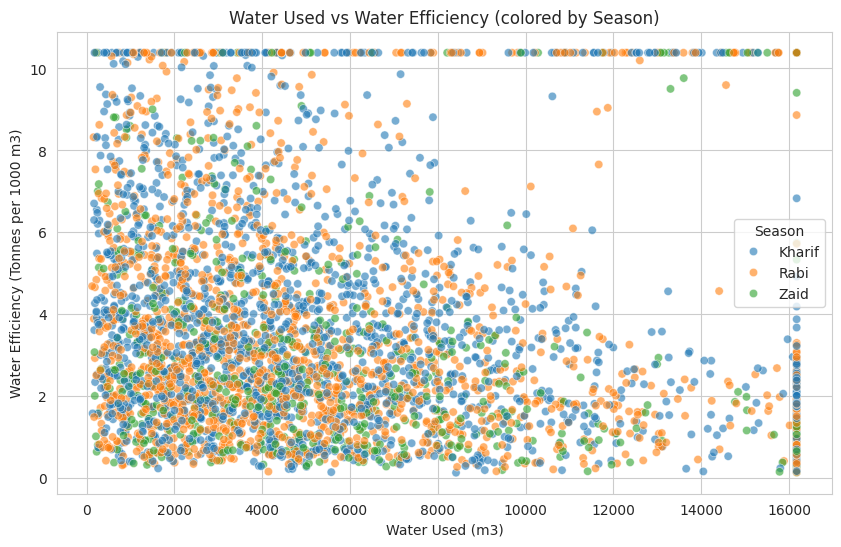

In [29]:
# Water used vs Water efficiency, colored by season
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Water_Used_m3', y='Water_Efficiency_t_per_1000m3', hue='Season', data=data, alpha=0.6)
plt.title('Water Used vs Water Efficiency (colored by Season)')
plt.xlabel('Water Used (m3)')
plt.ylabel('Water Efficiency (Tonnes per 1000 m3)')
plt.show()


## 11. Correlation Analysis

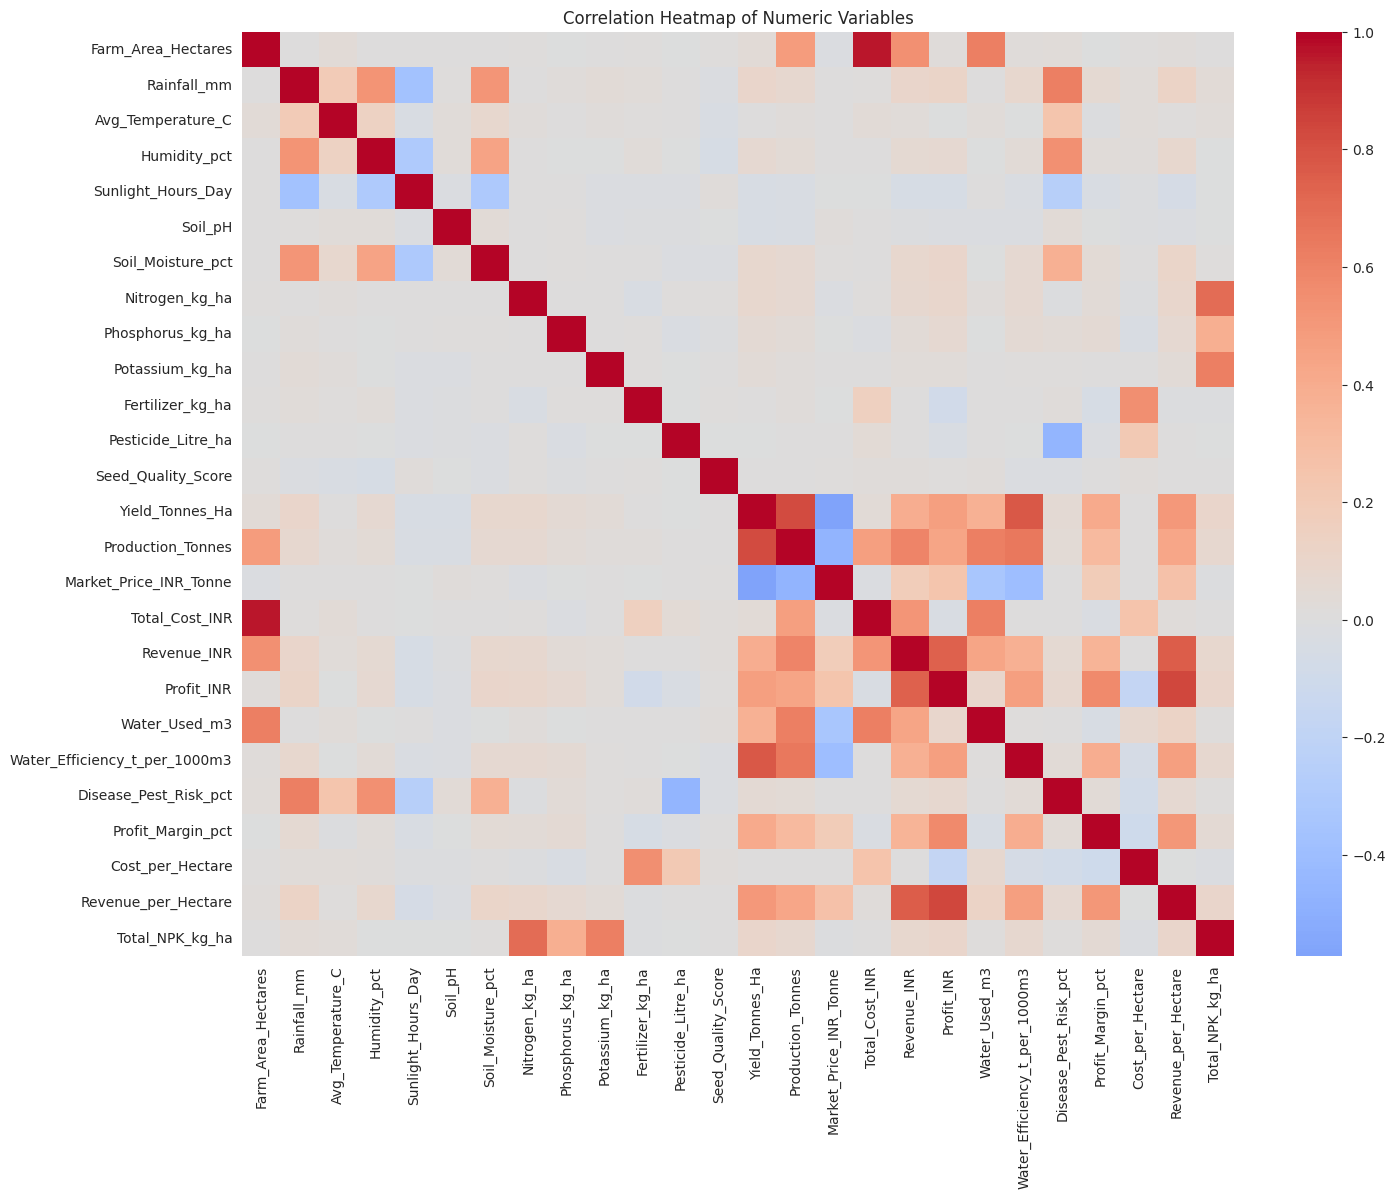

In [30]:
# Correlation matrix of numeric variables
numeric_data = data.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()


In [31]:
# Correlation of each variable specifically with Yield and Profit
corr_with_yield = corr_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False)
corr_with_profit = corr_matrix['Profit_INR'].sort_values(ascending=False)

print("Top correlations with Yield_Tonnes_Ha:\n", corr_with_yield.head(10))
print("\nTop correlations with Profit_INR:\n", corr_with_profit.head(10))


Top correlations with Yield_Tonnes_Ha:
 Yield_Tonnes_Ha                  1.000000
Production_Tonnes                0.821295
Water_Efficiency_t_per_1000m3    0.772986
Revenue_per_Hectare              0.497831
Profit_INR                       0.476181
Profit_Margin_pct                0.408989
Revenue_INR                      0.392342
Water_Used_m3                    0.370570
Rainfall_mm                      0.102223
Total_NPK_kg_ha                  0.093819
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_INR:
 Profit_INR                       1.000000
Revenue_per_Hectare              0.840010
Revenue_INR                      0.742273
Profit_Margin_pct                0.576212
Yield_Tonnes_Ha                  0.476181
Water_Efficiency_t_per_1000m3    0.472795
Production_Tonnes                0.436293
Market_Price_INR_Tonne           0.248264
Rainfall_mm                      0.110003
Total_NPK_kg_ha                  0.099298
Name: Profit_INR, dtype: float64


## 12. Statistical Significance Testing

We statistically test whether the seasonal differences observed above are significant, rather than due to random variation.


In [32]:
# ---- One-Way ANOVA: Is there a significant difference in Yield across Seasons? ----
kharif_yield = data[data['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi_yield   = data[data['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid_yield   = data[data['Season'] == 'Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = f_oneway(kharif_yield, rabi_yield, zaid_yield)
print(f"ANOVA on Yield across Seasons -> F-statistic: {f_stat:.3f}, p-value: {p_value:.5f}")

if p_value < 0.05:
    print("Result: Statistically significant difference in Yield across seasons (p < 0.05).")
else:
    print("Result: No statistically significant difference in Yield across seasons (p >= 0.05).")


ANOVA on Yield across Seasons -> F-statistic: 25.422, p-value: 0.00000
Result: Statistically significant difference in Yield across seasons (p < 0.05).


In [33]:
# ---- One-Way ANOVA: Is there a significant difference in Profit across Seasons? ----
kharif_profit = data[data['Season'] == 'Kharif']['Profit_INR']
rabi_profit   = data[data['Season'] == 'Rabi']['Profit_INR']
zaid_profit   = data[data['Season'] == 'Zaid']['Profit_INR']

f_stat_p, p_value_p = f_oneway(kharif_profit, rabi_profit, zaid_profit)
print(f"ANOVA on Profit across Seasons -> F-statistic: {f_stat_p:.3f}, p-value: {p_value_p:.5f}")

if p_value_p < 0.05:
    print("Result: Statistically significant difference in Profit across seasons (p < 0.05).")
else:
    print("Result: No statistically significant difference in Profit across seasons (p >= 0.05).")


ANOVA on Profit across Seasons -> F-statistic: 39.465, p-value: 0.00000
Result: Statistically significant difference in Profit across seasons (p < 0.05).


In [34]:
# ---- Kruskal-Wallis test ----
# Useful because our data may not be perfectly normally distributed
h_stat, p_val_kw = kruskal(kharif_yield, rabi_yield, zaid_yield)
print(f"Kruskal-Wallis test on Yield across Seasons -> H-statistic: {h_stat:.3f}, p-value: {p_val_kw:.5f}")


Kruskal-Wallis test on Yield across Seasons -> H-statistic: 68.705, p-value: 0.00000


In [35]:
# ---- Chi-Square Test: Is Crop choice associated with Season? ----
contingency = pd.crosstab(data['Crop'], data['Season'])
chi2, p_chi, dof, expected = chi2_contingency(contingency)
print(f"Chi-Square Test (Crop vs Season) -> Chi2: {chi2:.3f}, p-value: {p_chi:.5f}, dof: {dof}")

if p_chi < 0.05:
    print("Result: Crop choice is significantly associated with Season (p < 0.05).")
else:
    print("Result: No significant association between Crop choice and Season (p >= 0.05).")


Chi-Square Test (Crop vs Season) -> Chi2: 13.929, p-value: 0.45499, dof: 14
Result: No significant association between Crop choice and Season (p >= 0.05).


In [36]:
# ---- Chi-Square Test: Is Irrigation Method associated with Season? ----
contingency2 = pd.crosstab(data['Irrigation_Method'], data['Season'])
chi2_i, p_chi_i, dof_i, expected_i = chi2_contingency(contingency2)
print(f"Chi-Square Test (Irrigation vs Season) -> Chi2: {chi2_i:.3f}, p-value: {p_chi_i:.5f}, dof: {dof_i}")

if p_chi_i < 0.05:
    print("Result: Irrigation method usage is significantly associated with Season (p < 0.05).")
else:
    print("Result: No significant association between Irrigation method and Season (p >= 0.05).")


Chi-Square Test (Irrigation vs Season) -> Chi2: 3.513, p-value: 0.74228, dof: 6
Result: No significant association between Irrigation method and Season (p >= 0.05).


In [37]:
# ---- Pearson correlation test: Rainfall vs Yield (overall significance) ----
r_value, p_r = pearsonr(data['Rainfall_mm'], data['Yield_Tonnes_Ha'])
print(f"Pearson correlation (Rainfall vs Yield): r = {r_value:.3f}, p-value = {p_r:.5f}")


Pearson correlation (Rainfall vs Yield): r = 0.102, p-value = 0.00000


## 13. Key Insights

Run the cell below to auto-generate a quick data-driven summary. Review and refine these into your own written insights.


In [38]:
# Auto-generated summary of key seasonal findings
best_yield_season = seasonal_summary['Avg_Yield_Tonnes_Ha'].idxmax()
best_profit_season = seasonal_summary['Avg_Profit_INR'].idxmax()
highest_risk_season = seasonal_summary['Avg_Disease_Pest_Risk_pct'].idxmax()
most_water_efficient_season = seasonal_summary['Avg_Water_Efficiency'].idxmax()
highest_water_use_season = seasonal_summary['Avg_Water_Used_m3'].idxmax()

print("KEY SEASONAL INSIGHTS")
print("-" * 50)
print(f"1. Highest average yield is observed in: {best_yield_season}")
print(f"2. Highest average profit is observed in: {best_profit_season}")
print(f"3. Highest disease/pest risk is observed in: {highest_risk_season}")
print(f"4. Most water-efficient season: {most_water_efficient_season}")
print(f"5. Season with highest water consumption: {highest_water_use_season}")
print(f"6. ANOVA p-value for Yield across seasons: {p_value:.5f} -> "
      f"{'Significant' if p_value < 0.05 else 'Not significant'} seasonal effect")
print(f"7. Chi-Square p-value for Crop vs Season: {p_chi:.5f} -> "
      f"{'Significant' if p_chi < 0.05 else 'Not significant'} association")
print(f"8. Correlation between Rainfall and Yield: r = {r_value:.3f} "
      f"({'positive' if r_value > 0 else 'negative'} relationship)")


KEY SEASONAL INSIGHTS
--------------------------------------------------
1. Highest average yield is observed in: Kharif
2. Highest average profit is observed in: Kharif
3. Highest disease/pest risk is observed in: Kharif
4. Most water-efficient season: Kharif
5. Season with highest water consumption: Zaid
6. ANOVA p-value for Yield across seasons: 0.00000 -> Significant seasonal effect
7. Chi-Square p-value for Crop vs Season: 0.45499 -> Not significant association
8. Correlation between Rainfall and Yield: r = 0.102 (positive relationship)


Absolutely — here is a **clean, notebook-ready version** with concise headings and professional wording.

# Key Insights

### 1. Season has a significant impact on agricultural performance

Season has a measurable effect on both yield and profitability, with **Zaid emerging as a clear outlier**.

* **Kharif:** 852 mm rainfall, 2.25 t/ha yield, ₹91,728 average profit
* **Rabi:** 436 mm rainfall, 2.03 t/ha yield, ₹39,060 average profit
* **Zaid:** 299 mm rainfall, 1.81 t/ha yield, **–₹51,622 average profit**

Statistical tests confirm that the differences are significant:

* Yield: **ANOVA F = 25.42, p < 0.001**
* Profit: **ANOVA F = 39.47, p < 0.001**
* Kruskal-Wallis: **H = 68.7, p < 0.001**

This indicates that the seasonal differences are unlikely to be due to random variation.

### 2. Seasonal differences are driven primarily by environmental conditions

Crop selection and irrigation methods do not vary significantly across seasons.

* Crop mix: **χ² = 13.93, p = 0.455**
* Irrigation method: **χ² = 3.51, p = 0.742**

Farmers therefore appear to use broadly similar crop and irrigation choices across Kharif, Rabi, and Zaid. The major differences in performance are more likely associated with **rainfall, temperature, and other seasonal environmental conditions**.

### 3. Kharif has the highest disease and pest risk

Kharif records the highest disease/pest risk at **54.5%**, compared with:

* Rabi: **40.5%**
* Zaid: **38.2%**

Despite this higher risk, Kharif remains the most profitable season because its yield advantage more than offsets the additional pest and disease risk.

### 4. Water-use efficiency is more important than water quantity

Yield has a strong positive correlation with **water-use efficiency (r = 0.77)**, while its correlation with raw rainfall is comparatively weak (**r = 0.10**).

This suggests that agricultural performance depends more on **how efficiently available water is converted into crop output** than simply on the total amount of rainfall or water applied.

### 5. Crop and regional resilience varies considerably

Some crops and states demonstrate greater resilience to seasonal changes.

**Sugarcane** shows remarkably stable yields:

* Kharif: **5.43 t/ha**
* Rabi: **5.38 t/ha**
* Zaid: **5.42 t/ha**

In contrast, **Rice** experiences a substantial decline, falling from **2.70 t/ha in Kharif to 1.90 t/ha in Zaid**.

At the regional level, **Karnataka and Punjab** remain profitable or close to break-even across seasons, while **Andhra Pradesh, Gujarat, and Telangana** experience much larger swings, moving from strong Kharif profits to significant Zaid losses.

### 6. Data quality should be considered when interpreting profit margins

Although Kharif and Rabi show positive average profit in rupee terms, the **average profit margin is negative across all seasons**. This is largely influenced by a small number of extreme loss-making observations, including margins as low as **–1461%**.

Therefore, median values and outlier-resistant measures should also be considered before making final policy or business decisions.

---

# Conclusions

1. **Season significantly affects both agricultural yield and profitability**, with Kharif performing strongest and Zaid being structurally loss-prone under current conditions.

2. The seasonal effect appears to be driven mainly by **environmental conditions rather than changes in crop selection or irrigation methods**.

3. **Kharif combines the highest profitability with the highest disease and pest risk**, creating an important trade-off between productivity and risk.

4. **Water-use efficiency is a stronger predictor of yield than rainfall quantity**, highlighting efficiency improvements as an important intervention area.

5. Seasonal vulnerability is **not evenly distributed** across crops and regions. Sugarcane, Karnataka, and Punjab demonstrate comparatively strong resilience, while several other regions and crops are much more vulnerable during Zaid.

---

# Recommendations

### 1. Treat Zaid as a high-risk production season

Financial planning should account for the possibility of **low or negative margins during Zaid**, particularly in regions experiencing large seasonal swings.

### 2. Prioritize water-use efficiency

Investment should focus on **efficient irrigation scheduling, drip and sprinkler systems, soil-moisture retention, and improved water management** rather than simply increasing the quantity of water supplied.

### 3. Strengthen Kharif pest and disease management

Since Kharif has the highest disease/pest risk while also generating the highest profits, targeted **pest surveillance, preventive measures, and disease-management practices** could protect the season's profitability.

### 4. Promote resilient crops and practices

Crops such as **Sugarcane**, which demonstrate relatively stable yields across seasons, could be considered in regions where seasonal variability is particularly severe, subject to local water and sustainability constraints.

### 5. Learn from resilient regions

The practices used in **Karnataka and Punjab** could be examined to identify farming, irrigation, crop-management, or resource-utilization strategies that help maintain performance across seasons.

### 6. Validate extreme observations

The unusually large negative profit margins and extreme outliers should be **checked against the original data source**. Correcting potential data-entry or measurement errors will improve the reliability of subsequent conclusions and recommendations.
